日本語表記に対応させるためのライブラリ japanize-matplotlib をインストールする

In [18]:
!pip install japanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable


####  直線のグラフを描く
<pre>
xy軸, ラベル(原点,x,y)，グリッド, 目盛り，縦横比
</pre>

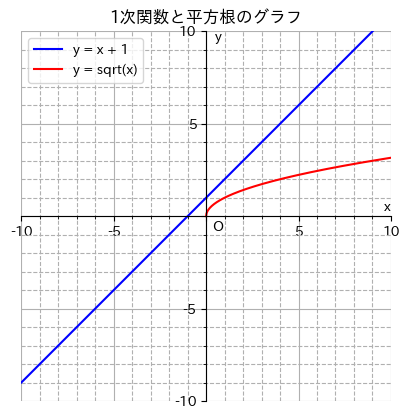

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# (1) データ作成
# 直線
x1 = np.linspace(-10, 10, 400)
y1 = x1 + 1

# 平方根 √x は x>=0 のみ
x2 = np.linspace(0, 10, 400)
y2 = np.sqrt(x2)

# (2) 領域の作成
fig, ax = plt.subplots()

# (3) 描画範囲の指定
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
# 縦横比1:1
ax.set_aspect('equal', adjustable='box')

# (4) xy軸を描く
# 軸を中央に配置
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# 軸ラベル（端）
ax.text(10, 0.8, 'x', ha='right', va='top')
ax.text(0.5, 10, 'y', ha='left', va='top')
# 原点0を消す
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "" if x == 0 else f"{x:g}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: "" if y == 0 else f"{y:g}"))
# ax.set_xticklabels(['' if t == 0 else int(t) for t in ax.get_xticks()])
# ax.set_yticklabels(['' if t == 0 else int(t) for t in ax.get_yticks()])
# 原点にO
ax.text(0.3, -0.8, 'O')

#  (5) 目盛り
# 主目盛り（5おき）
ax.set_xticks(np.arange(-10, 11, 5))
ax.set_yticks(np.arange(-10, 11, 5))
# 副目盛り（1おき）
ax.set_xticks(np.arange(-10, 11, 1), minor=True)
ax.set_yticks(np.arange(-10, 11, 1), minor=True)

# (6) グリッド（破線）
ax.grid(which='major', linestyle='-')
ax.grid(which='minor', linestyle='--')

# (7) グラフ描画（色分け＋ラベル）
ax.plot(x1, y1, color='blue', label='y = x + 1')
ax.plot(x2, y2, color='red', label='y = sqrt(x)')

# (8) タイトル，レジェンド
ax.set_title('1次関数と平方根のグラフ')
ax.legend()
# (9) 表示
plt.show()

床関数のグラフ

$y=\lfloor x \rfloor=[x]$

--------------- 床関数 ---------------


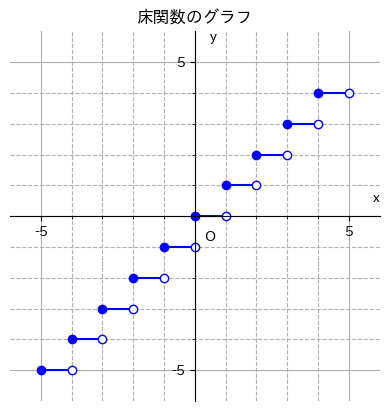

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

print('--------------- 床関数 ---------------' )

# (1) データ作成 -> なし

# (2) グラフの描画領域
fig, ax = plt.subplots()

# (3) 描画範囲の指定
# グラフの範囲
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
# 縦横比(アスペクト)を1:1にする
ax.set_aspect('equal', adjustable='box')

# (4) x軸とy軸の表示
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# 軸ラベル（端）
ax.text(6, 0.8, 'x', ha='right', va='top')
ax.text(0.5, 6, 'y', ha='left', va='top')
# 原点0を消す
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "" if x == 0 else f"{x:g}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: "" if y == 0 else f"{y:g}"))
# 原点Oを表示
ax.text(0.3, -0.8, 'O')

# (5) 目盛り
# 主目盛り（5 おき）
ax.set_xticks(np.arange(-5, 6, 5))
ax.set_yticks(np.arange(-5, 6, 5))
# 副目盛り（1 おき）
ax.set_xticks(np.arange(-5, 6, 1), minor=True)
ax.set_yticks(np.arange(-5, 6, 1), minor=True)

# (6) グリッド（破線）
ax.grid(which='major', linestyle='-')
ax.grid(which='minor', linestyle='--')

# (7) 床関数の階段状の線分を描画
for i in range(-5, 5):
    ax.plot([i, i+1], [np.floor(i)]*2, color='blue')
    ax.plot(i, np.floor(i), 'o', color='blue', markerfacecolor='blue')      # ●
    ax.plot(i+1, np.floor(i), 'o', color='blue', markerfacecolor='white')   # ○

# グラフタイトル
ax.set_title('床関数のグラフ')
#ax.legend()

# 画像として保存
# plt.savefig('01floor_function.png', dpi=300, bbox_inches='tight')

# 表示
plt.show()


試験の得点分布を可視化するために，ヒストグラムを描くことにした

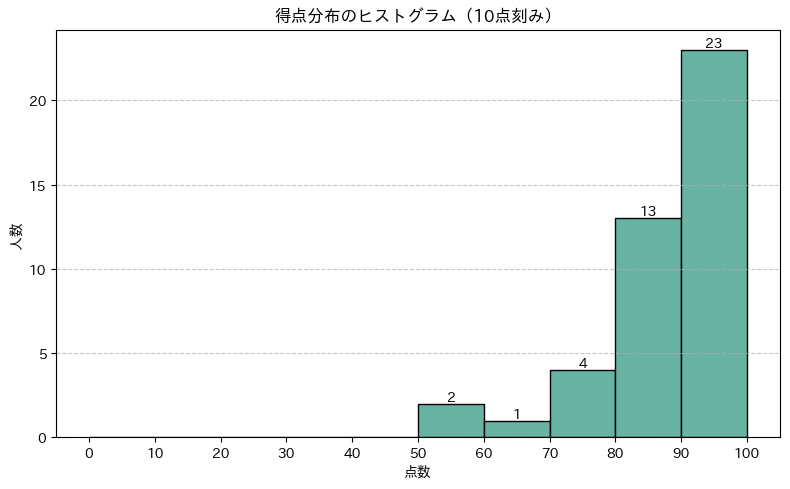

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# (1) データ作成
scores = [96, 90, 97, 51, -1, 88, 55, 100, 88, 100, 90, 100, 88, 98, 100,
          94, 100, 90, 73, 83, 74, 72, 86, 86, 67, 100, 82, 100, 100, 82,
          81, 73, 97, 100, 88, 84, 96, 94, 99, 100, 100, 88, 94, 88]

# 外れ値（-1など）を除外する場合
scores = [s for s in scores if 0 <= s <= 100]

# ビン（区間[0.100]内に11点を等間隔にとる）[0.10).[10,20),...,[90, 100]
# 最後の区間だけ，得点の幅が11となっている点に注意する
bins = np.linspace(0, 100, 11)

# (2) グラフの描画領域
fig, ax = plt.subplots(figsize=(8, 5))

# (4)(5) 軸や目盛り
ax.set_xticks(bins)
ax.set_xlabel('点数')
ax.set_ylabel('人数')

# (6) グリッド線
ax.grid(axis='y', linestyle='--', alpha=0.7)

# (7) ヒストグラム描画（countsを受け取る）
counts, bin_edges, patches = ax.hist(
    scores,
    bins=bins,
    edgecolor='black',
    color='#69b3a2'
)

# (7')ビンの上部に人数を表示
for count, edge_left, edge_right in zip(counts, bin_edges[:-1], bin_edges[1:]):
    x = (edge_left + edge_right) / 2  # ビンの中央
    if count > 0:
        ax.text(x, count, f'{int(count)}',
                ha='center', va='bottom', fontsize=10)

# (8) タイトル
ax.set_title('得点分布のヒストグラム（10点刻み）')

# 表示
plt.tight_layout()
# fig.savefig('./out/histogram.png')
plt.show()

100点満点の学生数を表示するために，最も右のビンの上部へその数値を色を付けて表示することにした．

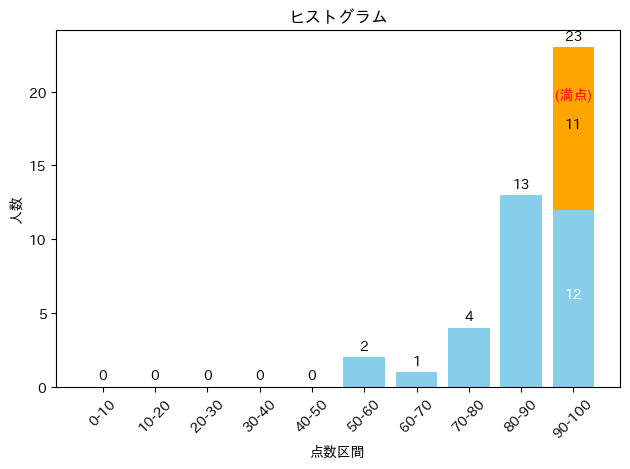

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# サンプルデータ（実際はここを差し替え）
np.random.seed(0)
scores = [96, 90, 97, 51, -1, 88, 55, 100, 88, 100, 90, 100, 88, 98, 100,
          94, 100, 90, 73, 83, 74, 72, 86, 86, 67, 100, 82, 100, 100, 82,
          81, 73, 97, 100, 88, 84, 96, 94, 99, 100, 100, 88, 94, 88]


# 0〜100を10区間
bins = np.linspace(0, 100, 11)
counts, edges = np.histogram(scores, bins=bins)

fig, ax = plt.subplots()

# --- 通常ビン ---
for i in range(len(counts) - 1):
    ax.bar([i], [counts[i]], color="skyblue")
    ax.text(i, counts[i] + 0.5, str(counts[i]), ha='center')

# --- 最後のビン（90–100）を分解 ---
last_low = len([x for x in scores if 90 <= x and x <= 99])  # 90-99
last_high = len([x for x in scores if x == 100])                # 100
total_last = last_low + last_high

x = len(counts) - 1

# 下部（90–99点）
ax.bar([x], [last_low], color="skyblue")

# 上部（100点）←積み上げ
ax.bar([x], [last_high], bottom=[last_low], color="orange")

# --- 内部ラベル ---
ax.text(x, last_low / 2, str(last_low), ha='center', color='white')      # 下部
if last_high > 0:
    ax.text(x, last_low + last_high / 2, str(last_high), ha='center')    # 上部
    ax.text(x, last_low + last_high / 2 + 2, f"(満点)", ha='center',  color='red')    # 上部

# --- 上端に合計 ---
ax.text(x, total_last + 0.5, str(total_last), ha='center')

# 軸設定
ax.set_xticks(range(len(edges) - 1))
ax.set_xticklabels([f"{int(edges[i])}-{int(edges[i+1])}" for i in range(len(edges) - 1)], rotation=45)

ax.set_xlabel("点数区間")
ax.set_ylabel("人数")
ax.set_title("ヒストグラム")

plt.tight_layout()
plt.show()


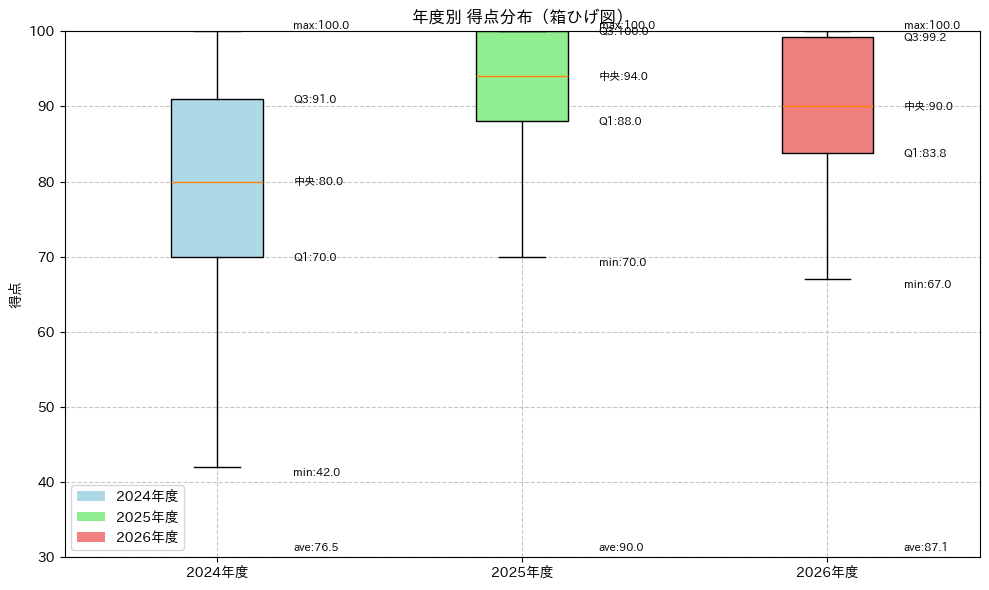

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.rcParams['font.family'] = 'IPAexGothic'

# (1) データ読み込み
df = pd.read_excel("examdata.xlsx", engine="openpyxl")

years = df.columns
data = [df[y].dropna().values for y in years]

# 外れ値除外で統計量
def calc_stats_no_outlier(values):
    # 各四分位数を求める
    q1 = np.percentile(values, 25)
    q2 = np.percentile(values, 50)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    filtered = values[(values >= lower) & (values <= upper)]

    return {
        "min": np.min(filtered),
        "q1": q1,
        "q2": q2,
        "q3": q3,
        "max": np.max(filtered)
    }

stats_list = [calc_stats_no_outlier(v) for v in data]

# (2) 描画領域の作成
fig, ax = plt.subplots(figsize=(10,6))

# (4)(5) 軸 
ax.set_ylim(30,100)
ax.set_ylabel("得点")

# (6) グリッド
ax.grid(True, linestyle='--', alpha=0.7)

# (7) 箱ひげ図の描画
box = ax.boxplot(
    data,
    tick_labels=[f"{y}年度" for y in years], #Matplotlib 3.9以降では labels → tick_labels に変更されています。
    patch_artist=True,
    showfliers=False
)

# 箱(box)の色
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# 五数要約の値をテキスト表示する
for i, stats in enumerate(stats_list):
    x = i + 1.25  # 横に少しずらす

    ax.text(x, stats['max'], f"max:{stats['max']:.1f}", fontsize=8, va='bottom')
    ax.text(x, stats['q3'],  f"Q3:{stats['q3']:.1f}", fontsize=8, va='center')
    ax.text(x, stats['q2'],  f"中央:{stats['q2']:.1f}", fontsize=8, va='center')
    ax.text(x, stats['q1'],  f"Q1:{stats['q1']:.1f}", fontsize=8, va='center')
    ax.text(x, stats['min'], f"min:{stats['min']:.1f}", fontsize=8, va='top')
    ax.text(x, 32, f"ave:{np.mean(data[i]):.1f}", fontsize=8, va='top')


# (8)凡例
# タイトル
ax.set_title("年度別 得点分布（箱ひげ図）")
# 凡例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[i], label=f"{years[i]}年度")
    for i in range(len(years))
]
ax.legend(handles=legend_elements)

# 表示
plt.tight_layout()
plt.show()
